In [10]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1e3, 1e3, 1e3], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
# filter_length = 2.0*snap['0_Diameters']
# weight='0_Volume'
# filter_type = 'gaussian'



In [11]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

gray = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))

widths_slicer = widths.copy()
widths_slicer[2] = 0.
center_slicer = center.copy
slicer = pa.Slicer(snap, center_slicer, widths_slicer, 'z', npix=2048)
extent = slicer.centered_extent.to('Mpc')

Attempting to get derived variable: 0_Volume...	[DONE]



In [12]:
# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'

# ax[i].xaxis.set_tick_params(which='major', size=7, width=1, direction='in', top='on')
# ax[i].xaxis.set_tick_params(which='minor', size=4, width=1, direction='in', top='on')
# ax[i].yaxis.set_tick_params(which='major', size=7, width=1, direction='in', right='on')
# ax[i].yaxis.set_tick_params(which='minor', size=4, width=1, direction='in', right='on')

In [13]:
weight='0_Volume'
filter_type = 'gaussian'
arepo_length = snap['0_Diameters'].uq
filter_length = 50*np.ones(snap['0_Diameters'].shape)*arepo_length

Attempting to get derived variable: 0_Diameters...	[DONE]



In [14]:
# when using the iterative filter we need to make sure that the particles required are
# loaded on the GPU. This can be achieved by increasing the search_radius
# to be larger than the maximum filter_radius of the iterative loop
# sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
#                         search_radius=20.*filter_length.value)

# when using the iterative filter we need to make sure that the particles required are
# loaded on the GPU. This can be achieved by increasing the search_radius
# to be larger than the maximum filter_radius of the iterative loop
sf_vec = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
                        search_radius=10.*filter_length.value)

In [15]:
e_B_smooth, e_m, e_b = tc.decompose_magnetic_energy(snap, sf_vec, '0_MagneticField', 
                                                      filter_length, weight, 
                                                      filter_type, iterative=False)

min/max/avg occupancy cartesian tiling 0 / 777 / 11.35


Attempting to get derived variable: 0_MagneticFieldStrength...	[DONE]



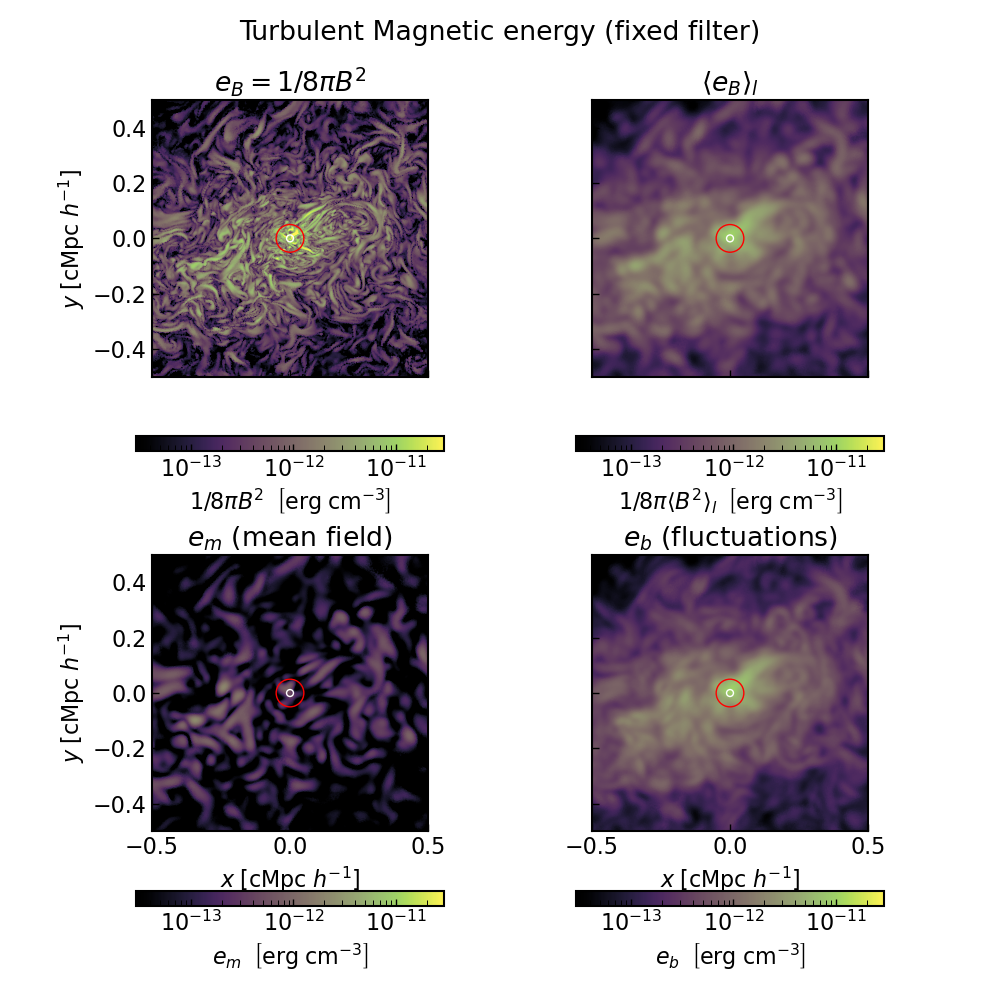

In [16]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import LogLocator
from matplotlib.patches import Circle

MAG_EN = slicer.slice_variable((1./(8.*np.pi))*snap['0_MagneticFieldStrength']**2).to_physical.to('erg / cm^3')
MAG_EN_smoothed = slicer.slice_variable(e_B_smooth).to_physical.to('erg / cm^3')
# MAG_EN_turb = slicer.slice_variable(turbVar)
MAG_EN_e_m = slicer.slice_variable(e_m).to_physical.to('erg / cm^3')
MAG_EN_e_b = slicer.slice_variable(e_b).to_physical.to('erg / cm^3')
# KIN_EN_e_t = slicer.slice_variable(e_t).to_physical.to('erg / cm^3')
# RHO_EN_SmoothField = slicer.slice_variable(smoothrho**2)


vmin = 5e-4*MAG_EN.value.max()
vmax = 5e-1*MAG_EN.value.max()
norm = LogNorm(vmin=vmin,vmax=vmax)

# vmin = -0.5*np.abs(MAG_EN_e_m.value).max()
# vmax =  0.5*np.abs(MAG_EN_e_m.value).max()
# norm1 = Normalize(vmin=-vmax,vmax=vmax)

# vmin = MAG_EN_e_s.value.min()
# vmax = KIN_EN_e_s.value.max()
# norm2 = LogNorm(vmin=vmin,vmax=vmax)

# cmap = cmr.fall
# cmap2 = cmr.rainforest
# cmap2 = cmr.prinsenvlag_r
# cmap2 = cmr.eclipse
cmap2 = cmr.ghostlight

fig, axes = plt.subplots(2,2, figsize=(10,10),sharex=True, sharey=True)

im00 = axes[0,0].imshow(
    MAG_EN.value, origin='lower', cmap=cmap2, norm=norm, extent=extent.value)
im01 = axes[0,1].imshow(
    MAG_EN_smoothed.value, origin='lower', cmap=cmap2, norm=norm, extent=extent.value)
im10 = axes[1,0].imshow(
    MAG_EN_e_m.value, origin='lower', cmap=cmap2, norm=norm, extent=extent.value)
# im10 = axes[1,0].imshow(
#     MAG_EN_turb.value, origin='lower', cmap=cmap1, norm=norm1, extent=extent.value)
im11 = axes[1,1].imshow(
    MAG_EN_e_b.value, origin='lower', cmap=cmap2, norm=norm, extent=extent.value)

for i in range(2):
    for j in range(2):
        circ = Circle((0.,0.),0.25*filter_length[0].to('Mpc').value, facecolor='None', edgecolor='w')
        axes[i,j].add_patch(circ)
        circ = Circle((0.,0.),filter_length[0].to('Mpc').value, facecolor='None', edgecolor='r')
        axes[i,j].add_patch(circ)

axes[0,0].set_title(r'$e_B = 1/8\pi B^2$')
axes[0,1].set_title(r'$\langle e_B \rangle_l$')
axes[1,0].set_title(r'$e_m$ (mean field)')
axes[1,1].set_title(r'$e_b$ (fluctuations)')

for i in range(2):
    axes[1,i].set_xlabel(extent.label('x'))

axes[0,0].set_ylabel(extent.label('y'))
axes[1,0].set_ylabel(extent.label('y'))


cbar00 = fig.colorbar(im00, orientation='horizontal',shrink=0.7)
cbar00.set_label(MAG_EN.label('1/8\\pi B^2'))

cbar01 = fig.colorbar(im01, orientation='horizontal',shrink=0.7)
cbar01.set_label(MAG_EN_smoothed.label('1/8\\pi \\langle B^2 \\rangle_l'))

cbar10 = fig.colorbar(im10, orientation='horizontal',shrink=0.7)
cbar10.set_label(MAG_EN_e_m.label('e_m'))

cbar11 = fig.colorbar(im11, orientation='horizontal',shrink=0.7)
cbar11.set_label(MAG_EN_e_b.label('e_{b}'))

fig.subplots_adjust(top=0.9,
bottom=0.05,
left=0.07,
right=0.95,
hspace=0.15,
wspace=0.00)

fig.suptitle('Turbulent Magnetic energy (fixed filter)',y=0.98)
plt.savefig('./Plots/magnetic_energy_fixed_filter.pdf', dpi=400)

plt.show()


In [26]:
snap['0_MagneticField'].uq.to_physical.to('Pa^(1/2)')

<PaicosQuantity 5.59106419e-07 Pa(1/2)>

In [21]:
Gauss = snap.uq('G')

In [22]:
Gauss

<PaicosQuantity 1. G>

In [24]:
(Gauss**2).unit.find_equivalent_units()

There are no equivalent units

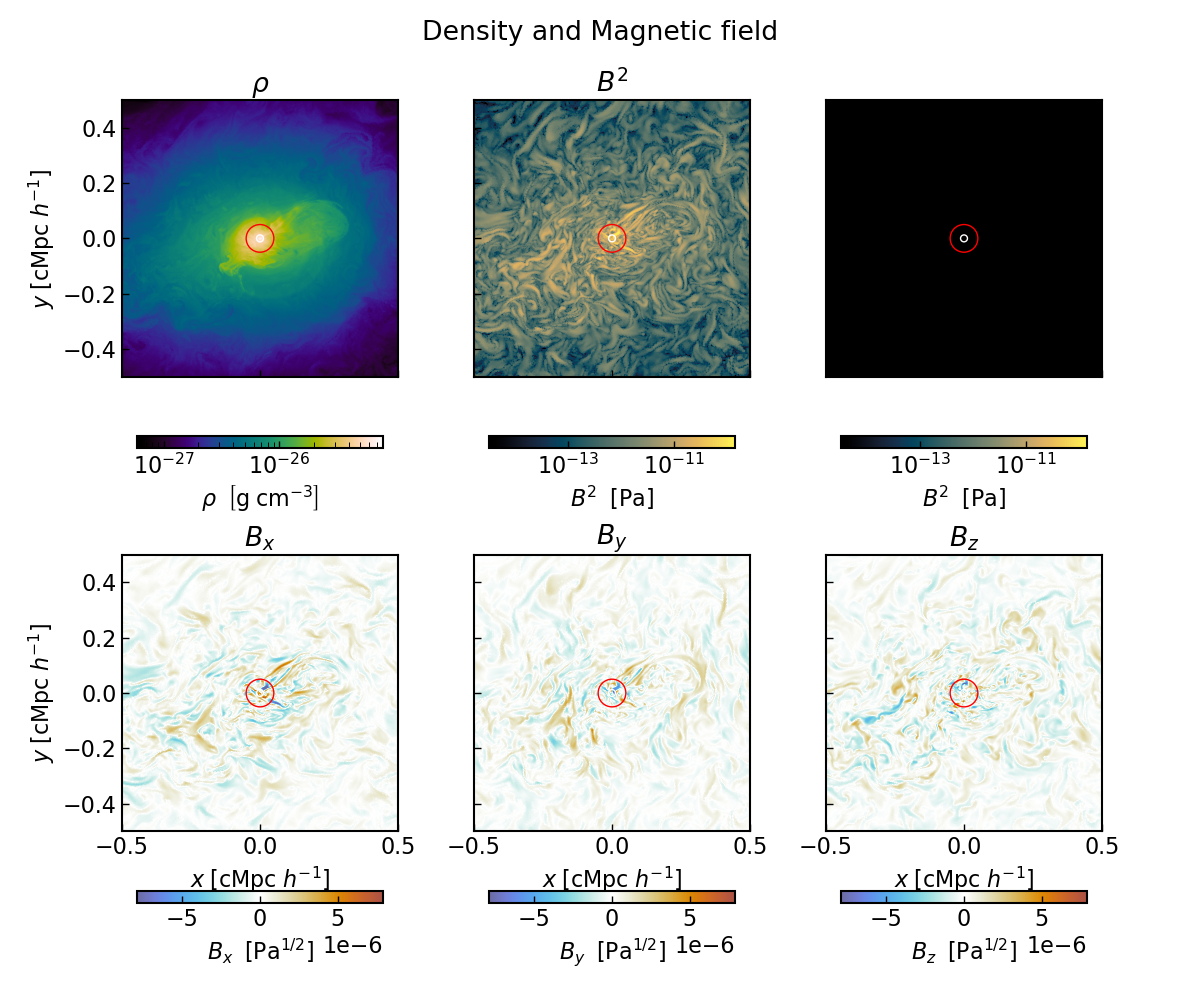

In [28]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import LogLocator
from matplotlib.patches import Circle

DEN = slicer.slice_variable(snap['0_Density']).to_physical.to('g / cm^3')
MAG2 = slicer.slice_variable(snap['0_MagneticFieldStrength']**2).to_physical.to('Pa')
# MAG_EN_turb = slicer.slice_variable(turbVar)
MAG_X = slicer.slice_variable(snap['0_MagneticField'][:,0]).to_physical.to('Pa^(1/2)')
MAG_Y = slicer.slice_variable(snap['0_MagneticField'][:,1]).to_physical.to('Pa^(1/2)')
MAG_Z = slicer.slice_variable(snap['0_MagneticField'][:,2]).to_physical.to('Pa^(1/2)')
# RHO_EN_SmoothField = slicer.slice_variable(smoothrho**2)


vmin = DEN.value.min()
vmax = DEN.value.max()
norm = LogNorm(vmin=vmin,vmax=vmax)

vmin = 50*MAG2.value.min()
vmax = MAG2.value.max()
norm1 = LogNorm(vmin=vmin,vmax=vmax)

vmin = -0.8*np.abs(MAG_X.value).max()
vmax =  0.8*np.abs(MAG_X.value).max()
norm2 = Normalize(vmin=-vmax,vmax=vmax)


# cmap = cmr.fall
cmap = cmr.rainforest
cmap1 = cmr.eclipse
cmap2 = cmr.prinsenvlag_r

fig, axes = plt.subplots(2,3, figsize=(12,10),sharex=True, sharey=True)

im00 = axes[0,0].imshow(
    DEN.value, origin='lower', cmap=cmap, norm=norm, extent=extent.value)
im01 = axes[0,1].imshow(
    MAG2.value, origin='lower', cmap=cmap1, norm=norm1, extent=extent.value)
im02 = axes[0,2].imshow(
    1e-10*MAG2.value, origin='lower', cmap=cmap1, norm=norm1, extent=extent.value)
im10 = axes[1,0].imshow(
    MAG_X.value, origin='lower', cmap=cmap2, norm=norm2, extent=extent.value)
# im10 = axes[1,0].imshow(
#     MAG_EN_turb.value, origin='lower', cmap=cmap1, norm=norm1, extent=extent.value)
im11 = axes[1,1].imshow(
    MAG_Y.value, origin='lower', cmap=cmap2, norm=norm2, extent=extent.value)
im12 = axes[1,2].imshow(
    MAG_Z.value, origin='lower', cmap=cmap2, norm=norm2, extent=extent.value)

for i in range(2):
    for j in range(3):
        circ = Circle((0.,0.),0.25*filter_length[0].to('Mpc').value, facecolor='None', edgecolor='w')
        axes[i,j].add_patch(circ)
        circ = Circle((0.,0.),filter_length[0].to('Mpc').value, facecolor='None', edgecolor='r')
        axes[i,j].add_patch(circ)

axes[0,0].set_title(r'$\rho$')
axes[0,1].set_title(r'$B^2$')
axes[1,0].set_title(r'$B_x$')
# axes[1,0].set_title(r'$B^2 - \langle B^2 \rangle_l$')
axes[1,1].set_title(r'$B_y$')
axes[1,2].set_title(r'$B_z$')
# axes[2,0].set_title(r'$B^2$ (on a uniform mesh)')

for i in range(3):
    axes[1,i].set_xlabel(extent.label('x'))

axes[0,0].set_ylabel(extent.label('y'))
axes[1,0].set_ylabel(extent.label('y'))


cbar00 = fig.colorbar(im00, orientation='horizontal',shrink=0.7)
cbar00.set_label(DEN.label('\\rho'))

cbar01 = fig.colorbar(im01, orientation='horizontal',shrink=0.7)
cbar01.set_label(MAG2.label(' B^2 '))

cbar02 = fig.colorbar(im02, orientation='horizontal',shrink=0.7)
cbar02.set_label(MAG2.label(' B^2 '))

cbar10 = fig.colorbar(im10, orientation='horizontal',shrink=0.7)
cbar10.set_label(MAG_X.label('B_x'))

# cbar10 = fig.colorbar(im10, orientation='horizontal',shrink=0.7)
# cbar10.set_label(MAG_EN_turb.label('B^2 - \\langle B^2 \\rangle_l'))

cbar11 = fig.colorbar(im11, orientation='horizontal',shrink=0.7)
cbar11.set_label(MAG_Y.label('B_y'))

cbar12 = fig.colorbar(im12, orientation='horizontal',shrink=0.7)
cbar12.set_label(MAG_Z.label('B_z'))

fig.subplots_adjust(top=0.9,
bottom=0.05,
left=0.07,
right=0.95,
hspace=0.15,
wspace=0.00)

fig.suptitle('Density and Magnetic field',y=0.98)
plt.savefig('./Plots/density_magnetic.pdf', dpi=400)

plt.show()
